# Phase 7 — Density Log Editing

**Field**: Dvalin, Norwegian Sea

The density log is the most borehole-sensitive of the three elastic inputs (RHOB, DT, DTS). This phase applies three sequential editing steps:

1. **DRHO-based suspect flagging** — samples where the density correction exceeds threshold are flagged as unreliable
2. **Null-interval infilling** — short NaN gaps are filled using the Gardner relation from VP_COMPOSITE (Faust-filled Vp from Phase 6), giving denser coverage than DT alone
3. **Lithology-specific exclusion flags** — coal and tight carbonate intervals are flagged separately so they can be excluded from rock physics trend fitting without being 'corrected' (their raw values are physically real, just not part of the clastic sand/shale system)

The output is `RHOB_OK`: the best-available density estimate at each depth, with clear documentation of where original data was used versus where an infill was applied.

In [1]:
import lasio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.transforms import blended_transform_factory
from pathlib import Path
import importlib, sys; sys.path.insert(0, '..')
import well_config; importlib.reload(well_config)
from well_config import get_cfg, set_plot_style, load_tops, ACTIVE_WELL

# ── Well selection ────────────────────────────────────────────────────────────
WELL_NAME = ACTIVE_WELL   # ← change ACTIVE_WELL in well_config.py to switch all notebooks at once
#WELL_NAME = "15_9-F-1A"  # ← uncomment to override for this notebook only
cfg       = get_cfg(WELL_NAME)
set_plot_style()

# ── Paths ─────────────────────────────────────────────────────────────────────
WELL_FILE    = Path('..') / cfg['las_file']
TOPS_FILE    = Path('..') / cfg['tops_file']
COMPUTED_IN  = Path(f'../wells/{WELL_NAME}_computed.parquet')
FLAGS_IN     = Path(f'../wells/{WELL_NAME}_flags.parquet')
DS_IN        = Path(f'../wells/{WELL_NAME}_depthshift.parquet')
FAUST_IN     = Path(f'../wells/{WELL_NAME}_faust.parquet')
OUT_FILE     = Path(f'../wells/{WELL_NAME}_rhob_ok.parquet')

# ── Editing thresholds (from config) ──────────────────────────────────────────
DRHO_EDIT_THRESH  = cfg['drho_edit_thresh']   # g/cc — above this, prefer Gardner infill
RHOB_COAL_MAX     = cfg['rhob_coal_max']      # g/cc — below this, flag as coal
RHOB_CARBONATE    = cfg['rhob_carbonate']     # g/cc — above this, flag as tight carbonate
INFILL_GAP_MAX    = int(cfg['infill_gap_max_m'] / 0.1)   # samples (0.1 m step)

# ── Gardner constants (from config) ────────────────────────────────────────────
GARDNER_A = cfg['gardner_a']
GARDNER_B = cfg['gardner_b']

## Step 7.1 — Load Data

In [2]:
las = lasio.read(WELL_FILE)
df  = las.df()
df.replace(-999.25, np.nan, inplace=True)
df.rename(columns=cfg.get('curve_map', {}), inplace=True)
df.index.name = 'DEPTH_MD'

df = df.join(pd.read_parquet(COMPUTED_IN), how='left')
df = df.join(pd.read_parquet(FLAGS_IN),    how='left')
ds_df = pd.read_parquet(DS_IN)
ds_cols = [c for c in ds_df.columns if c not in df.columns]
df = df.join(ds_df[ds_cols], how='left')
faust_df = pd.read_parquet(FAUST_IN)
df = df.join(faust_df[[c for c in faust_df.columns if c not in df.columns]], how='left')

LOG_TOP  = cfg['log_top']  if cfg['log_top']  is not None else df.index[0]
LOG_BASE = cfg['log_base'] if cfg['log_base'] is not None else df.index[-1]
sub = df.loc[LOG_TOP:LOG_BASE].copy()

f1a = load_tops(TOPS_FILE, cfg['tops_well_id'])
TOPS_MD       = dict(zip(f1a['PICKS'], f1a['DEPTH'])) if not f1a.empty else {}
RESERVOIR_TOP = f1a.iloc[-1]['PICKS'] if not f1a.empty else None

def nearest_idx(df, md):
    return df.index[np.argmin(np.abs(df.index.values - md))]

print(f"Logging interval: {LOG_TOP}–{LOG_BASE} m MD  ({len(sub):,} samples)")
print(f"RHOB valid samples: {sub['RHOB'].notna().sum():,}")
print(f"RHOB NaN samples  : {sub['RHOB'].isna().sum():,}")
print(f"VP_COMPOSITE valid: {sub['VP_COMPOSITE'].notna().sum():,}")

Logging interval: 0.0–4589.9832 m MD  (30,119 samples)
RHOB valid samples: 15,324
RHOB NaN samples  : 14,795
VP_COMPOSITE valid: 26,548


## Step 7.2 — Gardner-Predicted Density

The Gardner relation provides an independent, velocity-derived density estimate used as the infill source for suspect or missing RHOB intervals:

$$\rho_{\text{Gardner}} = 0.31 \times V_p^{0.25}  \quad (\text{g/cc, m/s})$$

Gardner prediction is approximate (±0.05–0.08 g/cc typical scatter), but is a physically consistent estimate unaffected by borehole rugosity — the root cause of density tool failure in washout zones.

**VP source**: `VP_COMPOSITE` (measured DT-derived Vp where available, Faust-predicted elsewhere from Phase 6). This gives Gardner density coverage across the full resistivity-logging interval, which is typically much wider than the sonic-logging interval alone.

In [3]:
# Use VP_COMPOSITE (Faust-filled) for Gardner — wider coverage than DT alone
sub['VP'] = 1e6 / sub['DT'] * 0.3048   # measured Vp from DT (kept for reference)
sub['VP_FOR_GARD'] = sub['VP_COMPOSITE'].fillna(sub['VP'])
sub['RHOB_GARD'] = GARDNER_A * sub['VP_FOR_GARD'] ** GARDNER_B

# Residual: measured minus Gardner
sub['RHOB_RESID'] = sub['RHOB'] - sub['RHOB_GARD']

# Compute a formation-specific Gardner offset
# (the raw Gardner may be systematically biased; a local offset corrects this)
# Use good data only (no suspect flag, both valid)
good = sub[(sub['DENSITY_SUSPECT'] == 0) & sub['RHOB'].notna() & sub['RHOB_GARD'].notna()]
global_offset = good['RHOB_RESID'].median()
sub['RHOB_GARD_CORR'] = sub['RHOB_GARD'] + global_offset

print(f"Gardner relation: RHOB = {GARDNER_A} × Vp^{GARDNER_B}  (g/cc, m/s)")
print(f"VP source: VP_COMPOSITE ({sub['VP_FOR_GARD'].notna().sum():,} valid; "
      f"DT-only would give {sub['VP'].notna().sum():,})")
print(f"Global RHOB − Gardner offset (median on good data): {global_offset:+.4f} g/cc")
print()
print("RHOB_GARD_CORR statistics:")
print(sub['RHOB_GARD_CORR'].describe().round(4).to_string())
print()
print("RHOB_RESID statistics (measured − Gardner):")
print(good['RHOB_RESID'].describe().round(4).to_string())

Gardner relation: RHOB = 0.31 × Vp^0.25  (g/cc, m/s)
VP source: VP_COMPOSITE (26,548 valid; DT-only would give 20,798)
Global RHOB − Gardner offset (median on good data): +0.1753 g/cc

RHOB_GARD_CORR statistics:
count    26548.0000
mean         2.4101
std          0.1155
min          2.1824
25%          2.3166
50%          2.3851
75%          2.4792
max          2.8830

RHOB_RESID statistics (measured − Gardner):
count    15238.0000
mean         0.1666
std          0.1006
min         -0.2857
25%          0.1037
50%          0.1753
75%          0.2366
max          0.7590


## Step 7.3 — Lithology Flags: Coal and Tight Carbonate

Coal and tight carbonate cement layers are real geological features that produce extreme density values. They are **not editing artefacts** and should not be 'corrected'. Instead, they are flagged so they can be excluded from the rock physics model trend fitting (which is calibrated for the sand/shale system):

- **COAL_FLAG**: RHOB < 1.80 g/cc (coal density typically 1.2–1.6 g/cc)
- **CALC_FLAG**: RHOB > 2.72 g/cc (calcite/dolomite cement: 2.71–2.87 g/cc)

These thresholds can be refined once the lithology crossplots (Phase 5) are examined more carefully.

In [4]:
sub['COAL_FLAG'] = ((sub['RHOB'] < RHOB_COAL_MAX) & sub['RHOB'].notna()).astype(int)
sub['CALC_FLAG'] = ((sub['RHOB'] > RHOB_CARBONATE) & sub['RHOB'].notna()).astype(int)

n_coal = sub['COAL_FLAG'].sum()
n_calc = sub['CALC_FLAG'].sum()
n_total = sub['RHOB'].notna().sum()

print(f"Lithology flag summary:")
print(f"  COAL_FLAG (RHOB < {RHOB_COAL_MAX} g/cc)  : {n_coal:4,}  ({100*n_coal/n_total:.1f}%)")
print(f"  CALC_FLAG (RHOB > {RHOB_CARBONATE} g/cc) : {n_calc:4,}  ({100*n_calc/n_total:.1f}%)")

# Where do coal intervals occur? (formation context)
if n_coal > 0:
    coal_depths = sub.loc[sub['COAL_FLAG'] == 1].index
    print(f"\n  Coal intervals (MD): {coal_depths.min():.1f}–{coal_depths.max():.1f} m")
    print(f"  RHOB range in coal : {sub.loc[sub['COAL_FLAG']==1,'RHOB'].min():.3f}–"
          f"{sub.loc[sub['COAL_FLAG']==1,'RHOB'].max():.3f} g/cc")

if n_calc > 0:
    calc_depths = sub.loc[sub['CALC_FLAG'] == 1].index
    print(f"\n  Carbonate intervals (MD): {calc_depths.min():.1f}–{calc_depths.max():.1f} m")
    print(f"  RHOB range in calc : {sub.loc[sub['CALC_FLAG']==1,'RHOB'].min():.3f}–"
          f"{sub.loc[sub['CALC_FLAG']==1,'RHOB'].max():.3f} g/cc")

Lithology flag summary:
  COAL_FLAG (RHOB < 1.8 g/cc)  :    0  (0.0%)
  CALC_FLAG (RHOB > 2.72 g/cc) :  153  (1.0%)

  Carbonate intervals (MD): 2211.3–4519.0 m
  RHOB range in calc : 2.720–3.177 g/cc


## Step 7.4 — Build RHOB_OK

The edited density log `RHOB_OK` is assembled using the following priority rules:

| Priority | Condition | Source used |
|----------|-----------|-------------|
| 1 | `DENSITY_SUSPECT = 0` and RHOB valid | Raw RHOB (best quality) |
| 2 | `DENSITY_SUSPECT = 1` and RHOB valid | Gardner-corrected (borehole-independent) |
| 3 | RHOB = NaN (short gaps ≤ 5 m) | Linear interpolation of RHOB_OK |
| 4 | RHOB = NaN (longer gaps) | Gardner-corrected (using VP_COMPOSITE) |

An `EDIT_FLAG` tracks which source was used at each sample:
- `0` — original RHOB used (no edit)
- `1` — Gardner replacement (suspect)
- `2` — interpolated infill
- `3` — Gardner infill (no original data)

In [5]:
# ── Initialise arrays ─────────────────────────────────────────────────────────
rhob_ok   = sub['RHOB'].values.copy().astype(float)
edit_flag = np.zeros(len(sub), dtype=int)

rhob_raw  = sub['RHOB'].values
rhob_gard = sub['RHOB_GARD_CORR'].values
suspect   = sub['DENSITY_SUSPECT'].values
drho_abs  = sub['DRHO'].abs().values

# ── Rule 2: replace suspect samples with Gardner ─────────────────────────────
# Only apply where DRHO exceeds the stricter threshold (raw correction > 0.15 g/cc)
mask_replace = (suspect == 1) & np.isfinite(rhob_raw) & (drho_abs >= DRHO_EDIT_THRESH)
rhob_ok[mask_replace]   = rhob_gard[mask_replace]
edit_flag[mask_replace] = 1

# ── Rules 3 & 4: fill NaN gaps ────────────────────────────────────────────────
rhob_series = pd.Series(rhob_ok, index=sub.index)

# Identify gap lengths
null_mask = np.isnan(rhob_ok)
null_runs = []
in_gap, gap_start, gap_len = False, 0, 0
for i, is_null in enumerate(null_mask):
    if is_null and not in_gap:
        in_gap, gap_start, gap_len = True, i, 1
    elif is_null and in_gap:
        gap_len += 1
    elif not is_null and in_gap:
        null_runs.append((gap_start, gap_start + gap_len, gap_len))
        in_gap = False
if in_gap:
    null_runs.append((gap_start, gap_start + gap_len, gap_len))

for gap_s, gap_e, gap_l in null_runs:
    if gap_l <= INFILL_GAP_MAX:
        # Linear interpolation between bracketing valid samples
        i_before = gap_s - 1
        i_after  = gap_e
        if i_before >= 0 and i_after < len(rhob_ok) and \
           np.isfinite(rhob_ok[i_before]) and np.isfinite(rhob_ok[i_after]):
            interp_vals = np.linspace(rhob_ok[i_before], rhob_ok[i_after], gap_l + 2)[1:-1]
            rhob_ok[gap_s:gap_e]   = interp_vals
            edit_flag[gap_s:gap_e] = 2
            continue
    # Longer gap or no valid brackets: use Gardner
    rhob_ok[gap_s:gap_e]   = rhob_gard[gap_s:gap_e]
    edit_flag[gap_s:gap_e] = 3

sub['RHOB_OK']   = rhob_ok
sub['EDIT_FLAG'] = edit_flag

# ── Summary ───────────────────────────────────────────────────────────────────
edit_names = {0: 'Original (no edit)', 1: 'Gardner replace (suspect)',
               2: 'Interpolation infill', 3: 'Gardner infill (NaN)'}
print("RHOB_OK edit flag summary:")
for flag_val, flag_name in edit_names.items():
    n = (sub['EDIT_FLAG'] == flag_val).sum()
    pct = 100 * n / len(sub)
    print(f"  Flag {flag_val}: {flag_name:<30} {n:5,} samples ({pct:.1f}%)")
print()
print(f"RHOB_OK remaining NaN: {sub['RHOB_OK'].isna().sum()}")
print(f"RHOB_OK range: {sub['RHOB_OK'].min():.3f}–{sub['RHOB_OK'].max():.3f} g/cc")

RHOB_OK edit flag summary:
  Flag 0: Original (no edit)             15,299 samples (50.8%)
  Flag 1: Gardner replace (suspect)         25 samples (0.1%)
  Flag 2: Interpolation infill              31 samples (0.1%)
  Flag 3: Gardner infill (NaN)           14,764 samples (49.0%)

RHOB_OK remaining NaN: 3553
RHOB_OK range: 2.133–3.129 g/cc


## Step 7.5 — RHOB vs RHOB_OK Comparison Display

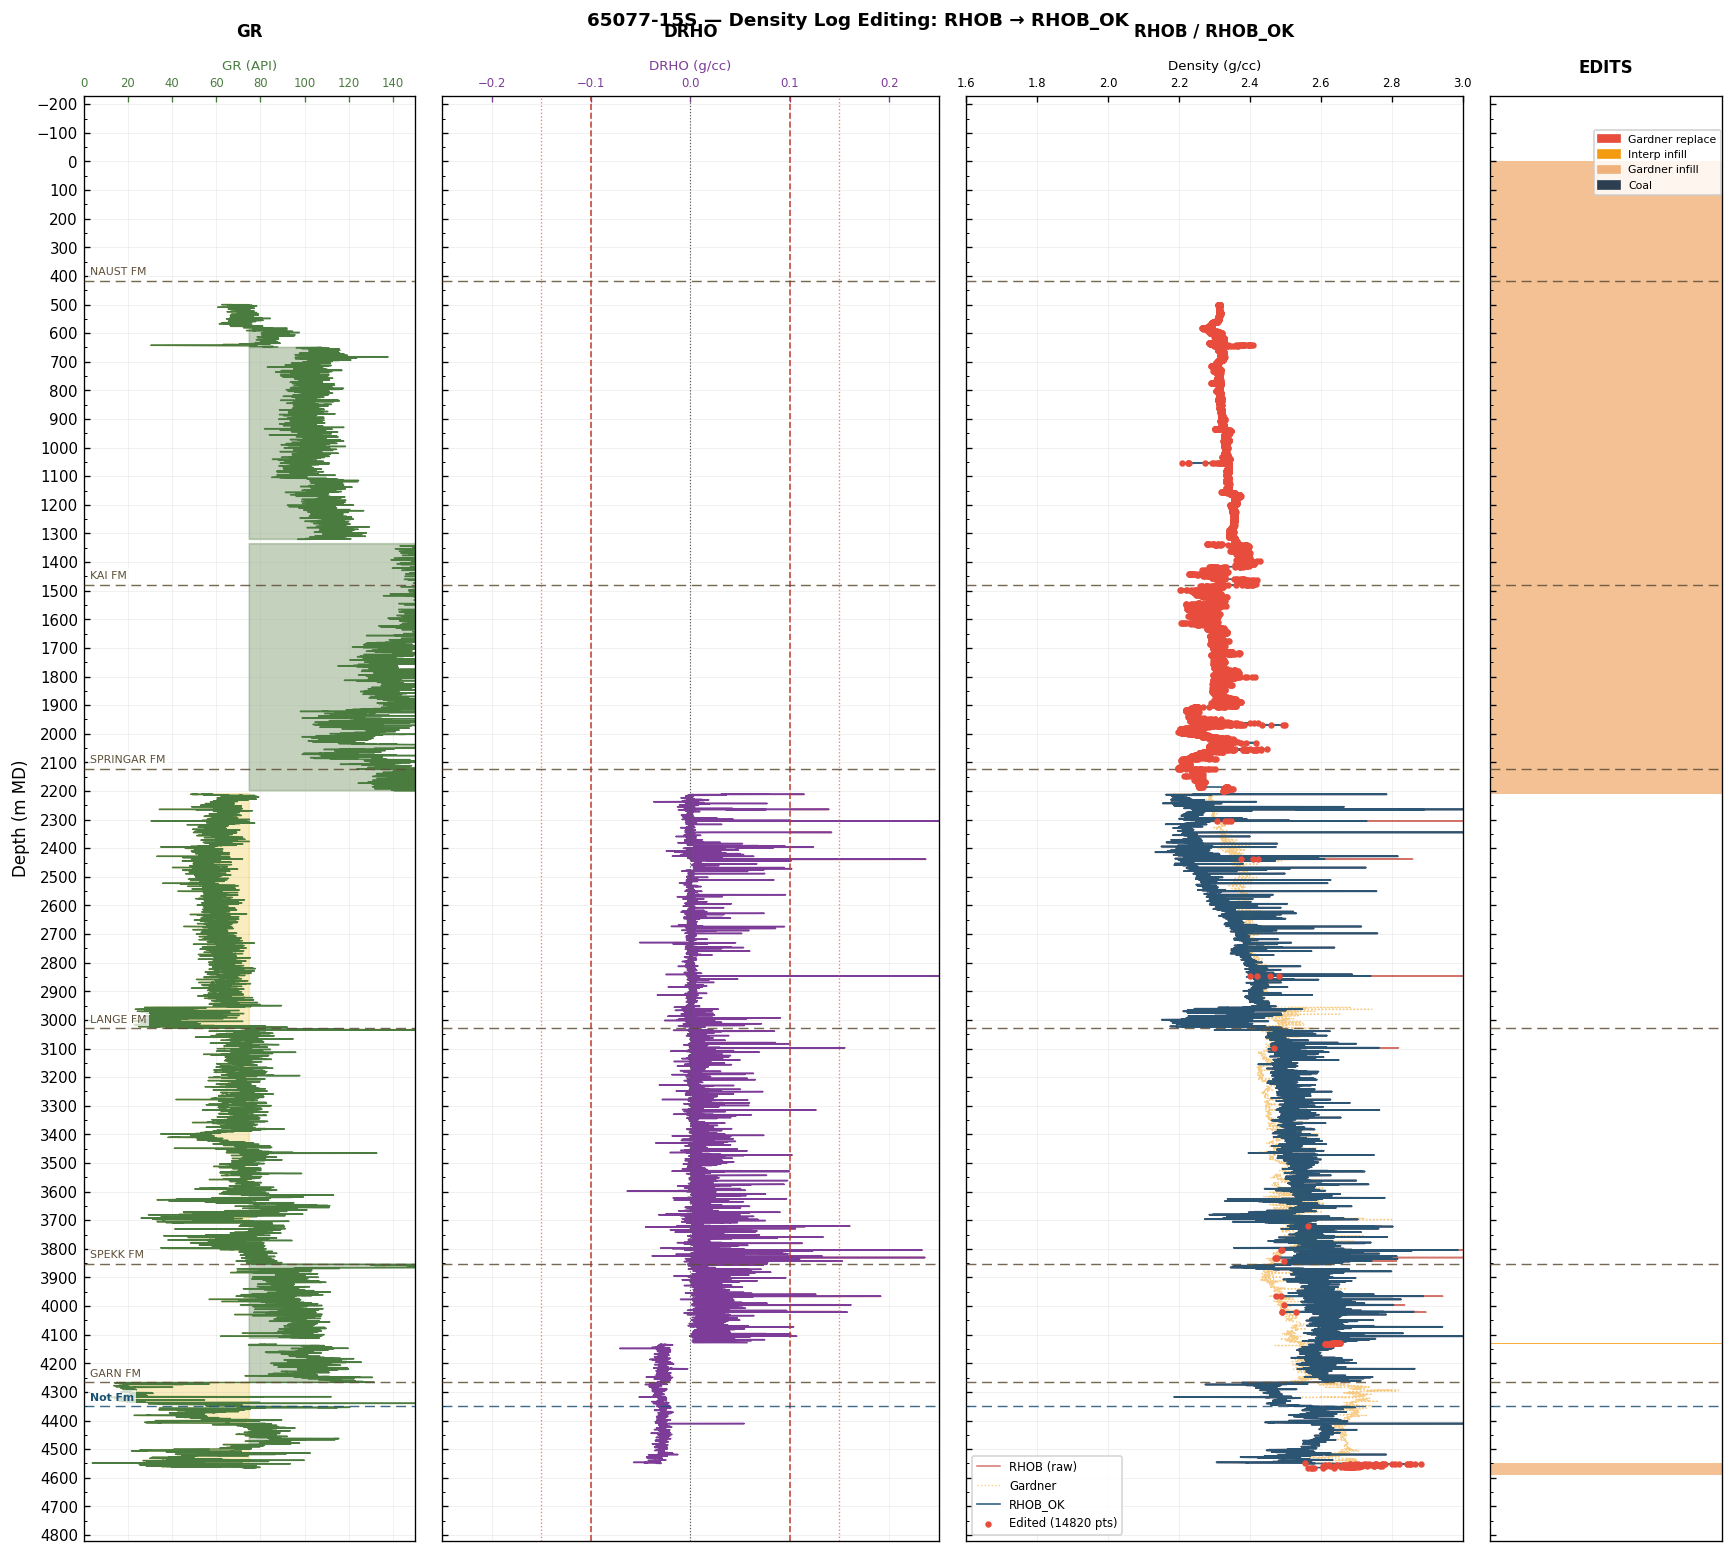

In [6]:
depth = sub.index.values

fig, axes = plt.subplots(1, 4, figsize=(15, 14), sharey=True,
                          gridspec_kw={'width_ratios': [1.0, 1.5, 1.5, 0.7]})
fig.subplots_adjust(top=0.93, bottom=0.07, left=0.07, right=0.98, wspace=0.07)

# ── Track 1: GR ──────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(sub['GR'], depth, color='#4A7C40', lw=0.8)
ax.fill_betweenx(depth, sub['GR'], 75,
                  where=sub['GR'] > 75, color='#6B8E5A', alpha=0.4)
ax.fill_betweenx(depth, sub['GR'], 75,
                  where=sub['GR'] <= 75, color='#F0D060', alpha=0.4)
ax.set_xlim(0, 150)
ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
ax.set_xlabel('GR (API)', color='#4A7C40', fontsize=8, labelpad=4)
ax.tick_params(axis='x', colors='#4A7C40', labelsize=7)
ax.set_ylabel('Depth (m MD)', fontsize=10)
ax.set_title('GR', fontsize=10, fontweight='bold', pad=14)
ax.grid(True, alpha=0.2, lw=0.5)
ax.invert_yaxis()
ax.yaxis.set_major_locator(ticker.MultipleLocator(100))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(50))

# ── Track 2: DRHO ─────────────────────────────────────────────────────────────
ax = axes[1]
drho = sub['DRHO']
ax.fill_betweenx(depth, drho, 0.10, where=drho > 0.10,
                  color='#C0392B', alpha=0.5)
ax.fill_betweenx(depth, drho, -0.10, where=drho < -0.10,
                  color='#C0392B', alpha=0.5)
ax.plot(drho, depth, color='#7D3C98', lw=0.9)
ax.axvline(0,     color='#555', lw=0.7, ls=':')
ax.axvline( 0.10, color='#C0392B', lw=1.0, ls='--', alpha=0.9)
ax.axvline(-0.10, color='#C0392B', lw=1.0, ls='--', alpha=0.9)
ax.axvline( DRHO_EDIT_THRESH, color='#E74C3C', lw=0.8, ls=':', alpha=0.7)
ax.axvline(-DRHO_EDIT_THRESH, color='#E74C3C', lw=0.8, ls=':', alpha=0.7)
ax.set_xlim(-0.25, 0.25)
ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
ax.set_xlabel('DRHO (g/cc)', color='#7D3C98', fontsize=8, labelpad=4)
ax.tick_params(axis='x', colors='#7D3C98', labelsize=7)
ax.set_title('DRHO', fontsize=10, fontweight='bold', pad=14)
ax.grid(True, alpha=0.2, lw=0.5)

# ── Track 3: RHOB vs RHOB_OK vs Gardner ───────────────────────────────────────
ax = axes[2]
ax.plot(sub['RHOB'],      depth, color='#C0392B', lw=0.9, alpha=0.7, label='RHOB (raw)')
ax.plot(sub['RHOB_GARD_CORR'], depth, color='#F39C12', lw=0.8, alpha=0.5, ls=':', label='Gardner')
ax.plot(sub['RHOB_OK'],   depth, color='#1A5276', lw=1.0, alpha=0.9, label='RHOB_OK')

edited = sub[sub['EDIT_FLAG'] > 0]
if len(edited) > 0:
    ax.scatter(edited['RHOB_OK'], edited.index,
               s=8, color='#E74C3C', zorder=5, label=f'Edited ({len(edited)} pts)')

coal = sub[sub['COAL_FLAG'] == 1]
if len(coal) > 0:
    ax.scatter(coal['RHOB'], coal.index,
               s=12, color='#2C3E50', marker='s', zorder=6, label='Coal')

ax.set_xlim(1.6, 3.0)
ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
ax.set_xlabel('Density (g/cc)', fontsize=8, labelpad=4)
ax.tick_params(axis='x', labelsize=7)
ax.legend(fontsize=7, loc='lower left', framealpha=0.8)
ax.set_title('RHOB / RHOB_OK', fontsize=10, fontweight='bold', pad=14)
ax.grid(True, alpha=0.2, lw=0.5)

# ── Track 4: Edit flag ────────────────────────────────────────────────────────
ax = axes[3]
flag_specs = [
    (1, '#E74C3C', 'Gardner\nreplace'),
    (2, '#F39C12', 'Interp\ninfill'),
    (3, '#F0B27A', 'Gardner\ninfill'),
]
for flag_val, color, _ in flag_specs:
    flag_mask = sub['EDIT_FLAG'].values == flag_val
    flag_depths = sub.index.values
    in_flag, seg_start = False, None
    for i, (d, v) in enumerate(zip(flag_depths, flag_mask)):
        if v and not in_flag:
            in_flag, seg_start = True, d
        elif not v and in_flag:
            ax.axhspan(seg_start, d, xmin=0, xmax=1,
                       color=color, alpha=0.8, linewidth=0)
            in_flag = False
    if in_flag:
        ax.axhspan(seg_start, flag_depths[-1], color=color, alpha=0.8, linewidth=0)

if len(coal) > 0:
    for d in coal.index.values:
        ax.axhspan(d - 0.05, d + 0.05, xmin=0, xmax=1,
                   color='#2C3E50', alpha=0.9, linewidth=0)

ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_title('EDITS', fontsize=10, fontweight='bold', pad=14)
import matplotlib.patches as mpatches
leg_patches = [
    mpatches.Patch(color='#E74C3C', label='Gardner replace'),
    mpatches.Patch(color='#F39C12', label='Interp infill'),
    mpatches.Patch(color='#F0B27A', label='Gardner infill'),
    mpatches.Patch(color='#2C3E50', label='Coal'),
]
ax.legend(handles=leg_patches, fontsize=6.5, loc='upper right',
          framealpha=0.85, bbox_to_anchor=(1.02, 0.98))

# ── Formation tops ─────────────────────────────────────────────────────────────
label_trans = blended_transform_factory(axes[0].transAxes, axes[0].transData)
for name, md_top in TOPS_MD.items():
    if not (depth.min() <= md_top <= depth.max()):
        continue
    lc = '#1A5276' if name == RESERVOIR_TOP else '#5D4E37'
    for ax in axes:
        ax.axhline(md_top, color=lc, lw=0.85, ls=(0,(7,4)), alpha=0.85, zorder=4)
    axes[0].text(0.02, md_top - (depth[-1]-depth[0])*0.003, name,
                 transform=label_trans, fontsize=6.5, va='bottom', ha='left',
                 color=lc, fontweight='bold' if name == RESERVOIR_TOP else 'normal',
                 bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.2),
                 zorder=5)

fig.suptitle(f'{WELL_NAME} — Density Log Editing: RHOB → RHOB_OK',
             fontsize=11, fontweight='bold')
plt.show()

## Step 7.6 — RHOB vs RHOB_OK Scatter Comparison

A 1:1 scatter plot between the raw RHOB and RHOB_OK confirms the editing is modest — the two curves are nearly identical for this well. Systematic departure from 1:1 would flag a processing error.

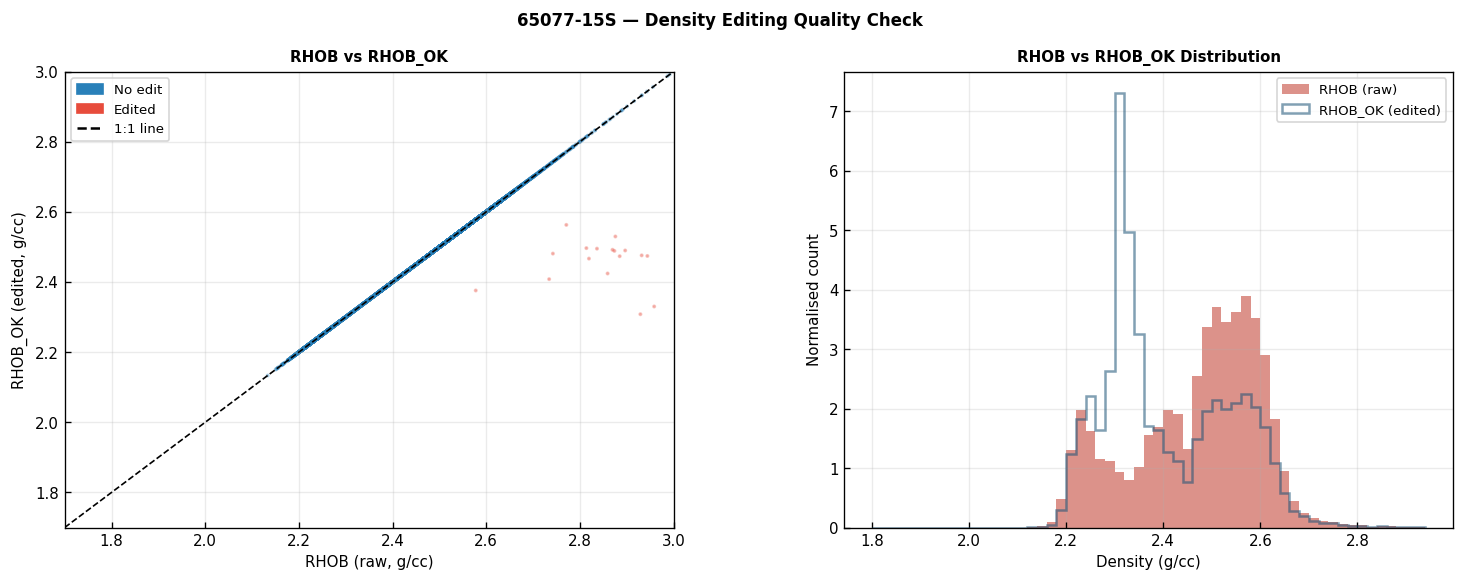

Edits applied to 25 samples (0.2%)
Max edit magnitude: 0.7838 g/cc
Mean edit          : -0.00076 g/cc


In [7]:
mask_both = sub['RHOB'].notna() & sub['RHOB_OK'].notna()
rhob_raw_vals = sub.loc[mask_both, 'RHOB'].values
rhob_ok_vals  = sub.loc[mask_both, 'RHOB_OK'].values
edit_flags    = sub.loc[mask_both, 'EDIT_FLAG'].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.subplots_adjust(left=0.08, right=0.97, top=0.88, bottom=0.12, wspace=0.28)

# Left: RHOB vs RHOB_OK scatter
ax = axes[0]
colors = np.where(edit_flags == 0, '#2980B9', '#E74C3C')
ax.scatter(rhob_raw_vals, rhob_ok_vals, c=colors, s=2, alpha=0.3, rasterized=True)
rng = [1.7, 3.0]
ax.plot(rng, rng, 'k--', lw=1.0, label='1:1 line')
ax.set_xlim(*rng); ax.set_ylim(*rng)
ax.set_xlabel('RHOB (raw, g/cc)', fontsize=9)
ax.set_ylabel('RHOB_OK (edited, g/cc)', fontsize=9)
ax.set_title('RHOB vs RHOB_OK', fontsize=9, fontweight='bold')
import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color='#2980B9', label='No edit'),
    mpatches.Patch(color='#E74C3C', label='Edited'),
    plt.Line2D([0],[0], color='k', ls='--', label='1:1 line'),
], fontsize=8)
ax.grid(True, alpha=0.25)

# Right: histogram of RHOB_OK vs RHOB
ax = axes[1]
bins = np.arange(1.8, 2.95, 0.02)
ax.hist(sub['RHOB'].dropna(), bins=bins, alpha=0.55, color='#C0392B',
        label='RHOB (raw)', histtype='stepfilled', density=True)
ax.hist(sub['RHOB_OK'].dropna(), bins=bins, alpha=0.55, color='#1A5276',
        label='RHOB_OK (edited)', histtype='step', lw=1.5, density=True)
ax.set_xlabel('Density (g/cc)', fontsize=9)
ax.set_ylabel('Normalised count', fontsize=9)
ax.set_title('RHOB vs RHOB_OK Distribution', fontsize=9, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

fig.suptitle(f'{WELL_NAME} — Density Editing Quality Check', fontsize=10, fontweight='bold')
plt.show()

diff = rhob_ok_vals - rhob_raw_vals
print(f"Edits applied to {(edit_flags > 0).sum():,} samples ({100*(edit_flags>0).mean():.1f}%)")
print(f"Max edit magnitude: {np.abs(diff).max():.4f} g/cc")
print(f"Mean edit          : {diff.mean():+.5f} g/cc")

## Step 7.7 — Save Output

In [8]:
out_cols = ['RHOB_OK', 'RHOB_GARD', 'RHOB_GARD_CORR', 'RHOB_RESID',
            'EDIT_FLAG', 'COAL_FLAG', 'CALC_FLAG']

out_full = sub[out_cols].reindex(df.index)
out_full.to_parquet(OUT_FILE)

print(f"Saved to : {OUT_FILE}")
print(f"Columns  : {out_cols}")
print(f"Rows     : {len(out_full):,}")
print()
if RESERVOIR_TOP and RESERVOIR_TOP in TOPS_MD:
    res_md = TOPS_MD[RESERVOIR_TOP]
    print(f"Preview at {RESERVOIR_TOP} (MD {res_md:.0f} m):")
    i = out_full.index[np.argmin(np.abs(out_full.index.values - res_md))]
else:
    i = out_full.index[-1]
    print(f"Preview at log base (MD {out_full.index[-1]:.0f} m):")
print(out_full.loc[i].to_string())

Saved to : ../wells/65077-15S_rhob_ok.parquet
Columns  : ['RHOB_OK', 'RHOB_GARD', 'RHOB_GARD_CORR', 'RHOB_RESID', 'EDIT_FLAG', 'COAL_FLAG', 'CALC_FLAG']
Rows     : 30,119

Preview at Not Fm (MD 4350 m):
RHOB_OK           2.580900
RHOB_GARD         2.494405
RHOB_GARD_CORR    2.669733
RHOB_RESID        0.086495
EDIT_FLAG         0.000000
COAL_FLAG         0.000000
CALC_FLAG         0.000000


---
## Phase 7 Summary

| Item | Value / Status |
|------|----------------|
| DRHO edit threshold | ±0.15 g/cc |
| Gardner Vp source | VP_COMPOSITE (Phase 6 Faust-filled) — wider than DT alone |
| Samples replaced by Gardner | See Step 7.7 output |
| Samples interpolation-infilled | See Step 7.7 output |
| Samples Gardner-infilled | See Step 7.7 output |
| Coal flag | See Step 7.3 output |
| Carbonate flag | See Step 7.3 output |
| RHOB_OK quality | See Step 7.6 output |
| Output saved | `wells/{WELL_NAME}_rhob_ok.parquet` |

**Next**: Notebook `08_elastic_qc.ipynb` — Vp/Vs QC, VP_OK/VS_OK build with Castagna VS fill (Phase 8).